# EDA Dataset Gambar Pokemon

Notebook ini membaca dataset gambar yang sudah diunduh dan diekstrak secara lokal. Tidak menggunakan KaggleHub, API, atau koneksi internet.

## 1. Konfigurasi lokasi dataset

Ubah `DATASET_DIR` ke folder yang berisi gambar hasil ekstraksi. Contoh ini memakai folder lokal proyek.

In [3]:
from pathlib import Path
from collections import Counter
import math
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from dotenv import load_dotenv

project_root = Path.cwd()
if not (project_root / '.env').exists():
    project_root = project_root.parent.parent
load_dotenv(project_root / '.env')
dataset_value = os.getenv('POKEMON_IMAGES_DIR')
if not dataset_value:
    raise ValueError('POKEMON_IMAGES_DIR belum diatur di file .env')
DATASET_DIR = Path(dataset_value)
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
image_paths = sorted(
    path for path in DATASET_DIR.rglob('*')
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)
print(f'Folder dataset: {DATASET_DIR}')
print(f'Jumlah gambar: {len(image_paths):,}')

Folder dataset: D:\Datasets\pokemon\compressed_images
Jumlah gambar: 19,926


## 2. Ringkasan file dan format

Menghitung jumlah gambar berdasarkan ekstensi dan jumlah file non-gambar.

In [4]:
extension_counts = Counter(path.suffix.lower() for path in image_paths)
display(pd.DataFrame(extension_counts.items(), columns=['extension', 'count']).sort_values('count', ascending=False))
all_files = [path for path in DATASET_DIR.rglob('*') if path.is_file()]
print(f'Total file: {len(all_files):,}')
print(f'File non-gambar: {len(all_files) - len(image_paths):,}')

,extension,count
0,.jpg,19926


Total file: 19,926
File non-gambar: 0


## 3. Validasi gambar dan statistik resolusi

Membuka setiap gambar lokal untuk mendeteksi file rusak serta mengukur resolusi, rasio aspek, dan ukuran file.

In [5]:
records = []
for path in image_paths:
    record = {
        'path': str(path),
        'filename': path.name,
        'extension': path.suffix.lower(),
        'file_size_bytes': path.stat().st_size,
        'valid': False,
        'format': None,
        'width': None,
        'height': None,
        'aspect_ratio': None,
        'error': None,
    }
    try:
        with Image.open(path) as image:
            image.verify()
        with Image.open(path) as image:
            width, height = image.size
            record.update({'valid': True, 'format': image.format, 'width': width, 'height': height, 'aspect_ratio': round(width / height, 4) if height else None})
    except (OSError, UnidentifiedImageError, ValueError) as error:
        record['error'] = str(error)
    records.append(record)

image_df = pd.DataFrame(records)
print(f"Gambar valid: {image_df['valid'].sum():,}/{len(image_df):,}")
print(f"Gambar rusak: {(~image_df['valid']).sum():,}")
display(image_df.head())
display(image_df.loc[image_df['valid'], ['width', 'height', 'aspect_ratio', 'file_size_bytes']].describe())

Gambar valid: 19,926/19,926
Gambar rusak: 0


,path,filename,extension,file_size_bytes,valid,format,width,height,aspect_ratio,error
0,D:\Datasets\pokemon\compressed_images\base1-1.jpg,base1-1.jpg,.jpg,112850,True,JPEG,640,640,1.0,None
1,D:\Datasets\pokemon\compressed_images\base1-10...,base1-10.jpg,.jpg,101804,True,JPEG,640,640,1.0,None
2,D:\Datasets\pokemon\compressed_images\base1-10...,base1-100.jpg,.jpg,55719,True,JPEG,640,640,1.0,None
3,D:\Datasets\pokemon\compressed_images\base1-10...,base1-101.jpg,.jpg,84587,True,JPEG,640,640,1.0,None
4,D:\Datasets\pokemon\compressed_images\base1-10...,base1-102.jpg,.jpg,73500,True,JPEG,640,640,1.0,None


,width,height,aspect_ratio,file_size_bytes
count,19926.0,19926.0,19926.0,19926.000000
mean,640.0,640.0,1.0,111204.740088
std,0.0,0.0,0.0,17865.501131
min,640.0,640.0,1.0,35054.000000
25%,640.0,640.0,1.0,99366.000000
50%,640.0,640.0,1.0,110008.000000
75%,640.0,640.0,1.0,121549.750000
max,640.0,640.0,1.0,221412.000000


## 4. Ringkasan resolusi untuk Data Card

Cell ini merangkum resolusi minimum, maksimum, rata-rata, median, dan resolusi yang paling sering muncul. Gunakan output ini untuk mengisi bagian format dan resolusi gambar pada Data Card.

In [9]:
resolution_df = valid_df[['width', 'height']].copy()
resolution_df['resolution'] = resolution_df['width'].astype(int).astype(str) + ' x ' + resolution_df['height'].astype(int).astype(str)

print('Ringkasan resolusi (piksel):')
display(resolution_df[['width', 'height']].agg(['count', 'min', 'max', 'mean', 'median']).round(2))

print('Resolusi paling sering:')
display(resolution_df['resolution'].value_counts().head(10).rename_axis('resolution').to_frame('count'))


Ringkasan resolusi (piksel):


,width,height
count,19926.0,19926.0
min,640.0,640.0
max,640.0,640.0
mean,640.0,640.0
median,640.0,640.0


Resolusi paling sering:


,count
resolution,
640 x 640,19926


## 4. Distribusi resolusi dan rasio aspek

Visualisasi untuk melihat konsistensi ukuran gambar.

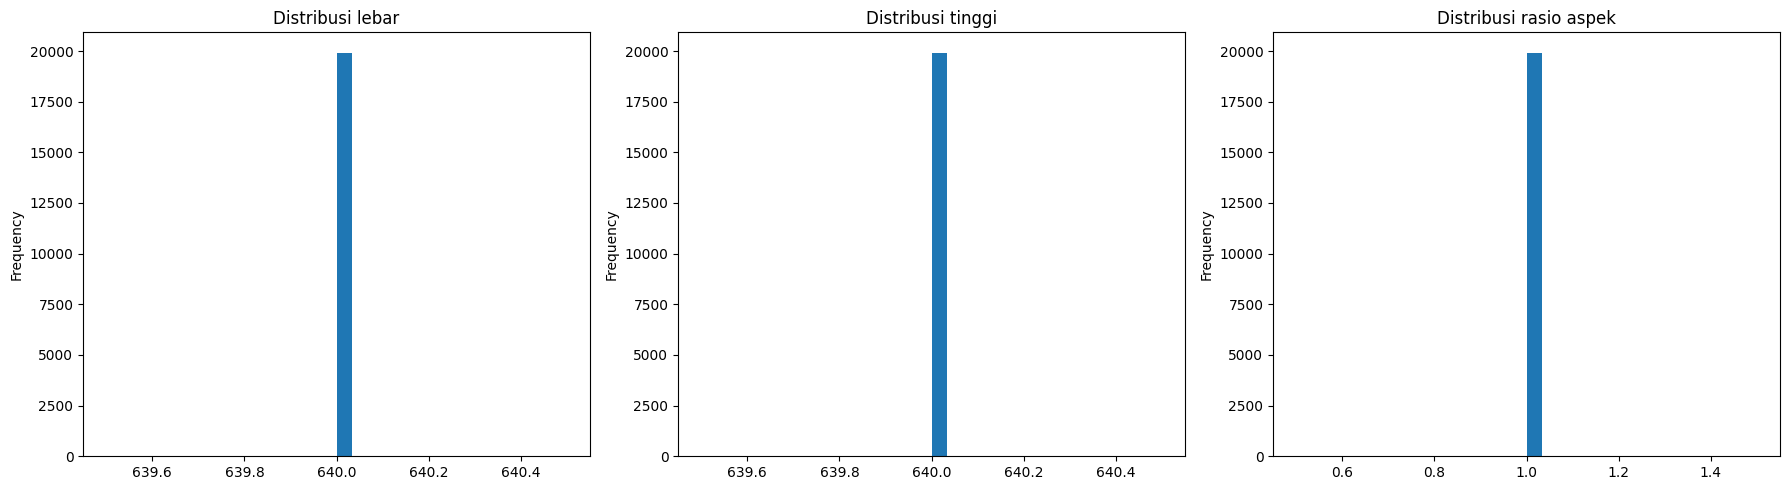

In [6]:
valid_df = image_df[image_df['valid']].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
valid_df['width'].plot(kind='hist', bins=30, ax=axes[0], title='Distribusi lebar')
valid_df['height'].plot(kind='hist', bins=30, ax=axes[1], title='Distribusi tinggi')
valid_df['aspect_ratio'].plot(kind='hist', bins=30, ax=axes[2], title='Distribusi rasio aspek')
plt.tight_layout()
plt.show()

## 5. Pemeriksaan visual sampel

Menampilkan maksimal 12 gambar valid secara acak.

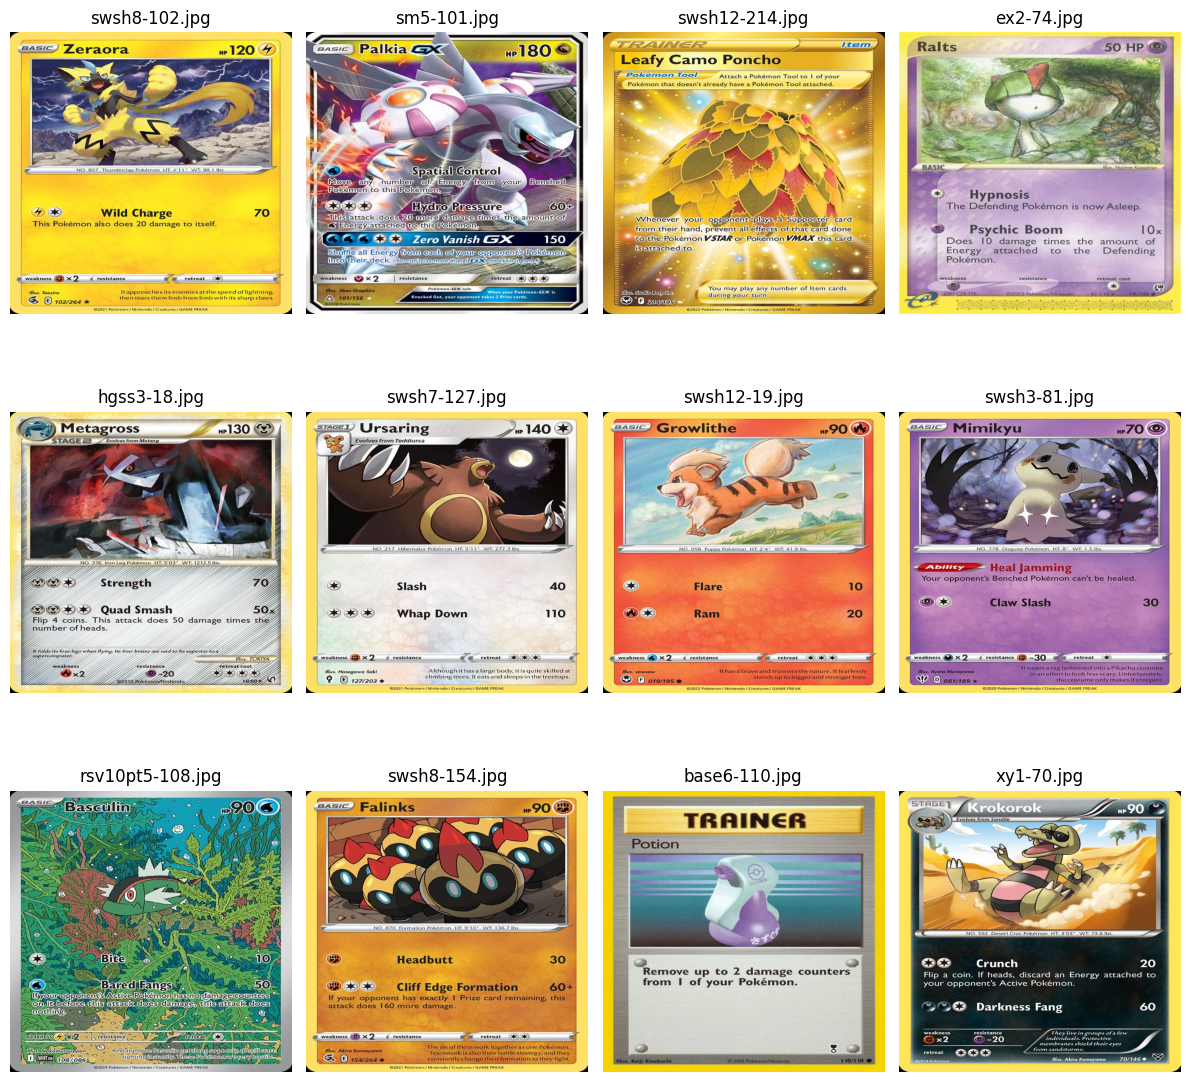

In [7]:
sample_size = min(12, len(valid_df))
sample_df = valid_df.sample(sample_size, random_state=42) if sample_size else valid_df
columns = 4
rows = math.ceil(sample_size / columns) if sample_size else 1
fig, axes = plt.subplots(rows, columns, figsize=(12, rows * 4))
axes = list(axes.flat) if hasattr(axes, 'flat') else [axes]
for axis, (_, record) in zip(axes, sample_df.iterrows()):
    with Image.open(record['path']) as image:
        axis.imshow(image)
    axis.set_title(record['filename'])
    axis.axis('off')
for axis in axes[sample_size:]:
    axis.axis('off')
plt.tight_layout()
plt.show()

## 6. Menyimpan audit

Menyimpan hasil pemeriksaan ke CSV di folder dataset.

In [ ]:
audit_path = DATASET_DIR / 'image_eda_audit.csv'
image_df.to_csv(audit_path, index=False)
print(f'Hasil audit: {audit_path}')